In [2]:
import pandas as pd
df=pd.read_csv('Shop Direct Sale Data For Research.csv')
df.head()

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales
0,1,1/1/2017,Ruby Patel,Stockholm,Sweden,Stockholm,North,Home Office,Office Supplies,Economy Plus,Paper,"Enermax Note Cards, Premium",3,9,36,45
1,2,1/3/2017,Summer Hayward,Southport,United Kingdom,England,North,Consumer,Furniture,Economy,Bookcases,"Dania Corner Shelving, Traditional",7,255,599,854
2,3,1/4/2017,Devin Huddleston,Valence,France,Auvergne-Rhône-Alpes,Central,Consumer,Office Supplies,Economy,Art,"Binney & Smith Sketch Pad, Easy-Erase",3,48,92,140
3,4,1/4/2017,Mary Parker,Birmingham,United Kingdom,England,North,Corporate,Office Supplies,Economy,Art,"Boston Markers, Easy-Erase",2,9,18,27
4,5,1/5/2017,Daniel Burke,Echirolles,France,Auvergne-Rhône-Alpes,Central,Home Office,Office Supplies,Priority,Art,"Binney & Smith Pencil Sharpener, Water Color",3,40,50,90


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4115 entries, 0 to 4114
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order ID       4115 non-null   int64 
 1   Order Date     4115 non-null   object
 2   Customer Name  4115 non-null   object
 3   City           4115 non-null   object
 4   Country        4115 non-null   object
 5   State          4115 non-null   object
 6   Region         4115 non-null   object
 7   Segment        4115 non-null   object
 8   Category       4115 non-null   object
 9   Ship Mode      4115 non-null   object
 10  Sub-Category   4115 non-null   object
 11  Product Name   4115 non-null   object
 12  Quantity       4115 non-null   int64 
 13  Cost           4115 non-null   int64 
 14  Profit         4115 non-null   int64 
 15  Sales          4115 non-null   int64 
dtypes: int64(5), object(11)
memory usage: 514.5+ KB


In [4]:
df.describe()

,Order ID,Quantity,Cost,Profit,Sales
count,4115.000000,4115.000000,4115.000000,4115.000000,4115.000000
mean,2058.000000,3.747266,155.673633,152.361361,308.034994
std,1188.042508,2.174294,319.455633,295.423113,511.485538
min,1.000000,1.000000,0.000000,1.000000,3.000000
25%,1029.500000,2.000000,18.000000,19.000000,50.000000
50%,2058.000000,3.000000,50.000000,50.000000,120.000000
75%,3086.500000,5.000000,144.000000,146.000000,322.000000
max,4115.000000,14.000000,4476.000000,3460.000000,6517.000000


In [5]:
#kategoriya buyicha 
df.groupby('Category')[['Sales', 'Profit']].sum()

,Sales,Profit
Category,,
Furniture,568595,274971
Office Supplies,421593,212662
Technology,277376,139334


In [6]:
df.groupby('Country')['Sales'].sum()

Country
Austria            41276
Belgium            24509
Denmark             4083
Finland            12525
France            348322
Germany           236399
Ireland             8756
Italy             130571
Netherlands        36296
Norway              8854
Portugal            9332
Spain             140397
Sweden             17962
Switzerland        11443
United Kingdom    236839
Name: Sales, dtype: int64

In [7]:
df.groupby(['Country','Region'])[['Sales','Profit']].sum().sort_values(by='Sales',ascending=False)

,,Sales,Profit
Country,Region,,
France,Central,348322,167791
United Kingdom,North,236839,113980
Germany,Central,236399,120387
Spain,South,140397,69775
Italy,South,130571,67977
Austria,Central,41276,18715
Netherlands,Central,36296,19571
Belgium,Central,24509,12972
Sweden,North,17962,7649


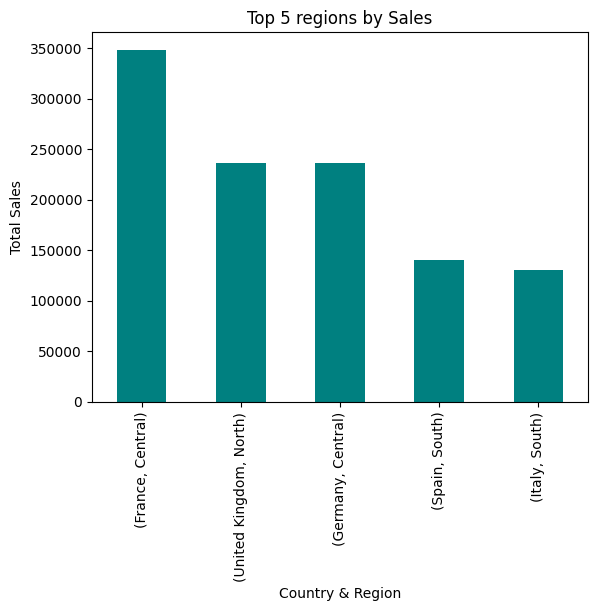

In [8]:
import matplotlib.pyplot as plt
top_regions=df.groupby(['Country','Region'])[['Sales']].sum().sort_values(by='Sales',ascending=False).head(5)

top_regions.plot(kind='bar',color='teal',legend=False )
plt.title('Top 5 regions by Sales')
plt.xlabel('Country & Region')
plt.ylabel('Total Sales')
plt.show()


In [10]:
df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)


,Sales,Profit
Segment,,
Consumer,680538,343972
Corporate,378578,181292
Home Office,208448,101703


In [ ]:
#order datani data farmatga utakazamiz
df['Order Date']=pd.to_datetime(df['Order Date'])
df.to_csv('Shop Direct Sale Data For Research.csv', index=False)

In [ ]:
df['Year'] = df['Order Date'].dt.year
#yillar kesimida savdo va foyda
df.groupby('Year')[['Sales', 'Profit']].sum()

,Sales,Profit
Year,,
2017,229391,111513
2018,289555,153298
2019,344917,173170
2020,403701,188986


In [12]:
#Qaysi segmentda savdo kup
df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)


,Sales,Profit
Segment,,
Consumer,680538,343972
Corporate,378578,181292
Home Office,208448,101703


In [ ]:
#yetkazib berish usullari
df.groupby('Ship Mode')[['Sales','Profit']].sum().sort_values(by='Sales', ascending=False)


In [16]:
#zarar keltirgan mahsulot
loss_products=df[df['Profit']<0][['Product Name', 'Sales', 'Profit', 'Country']]
print(loss_products)

Empty DataFrame
Columns: [Product Name, Sales, Profit, Country]
Index: []


In [15]:
#umumiy sales
customer_sales=df.groupby('Customer Name')[['Sales','Profit']].sum()
print(customer_sales)

                  Sales  Profit
Customer Name                  
Aaron Bootman      1635     817
Aaron Cunningham    820     670
Aaron Davey        1862     743
Aaron Macrossan      81      25
Abbie Perry         619     491
...                 ...     ...
Zara Loton         1570     387
Zara Money          785     237
Zoe Lanigan        2358    1729
Zoe Lowin           565     164
Zona Meyer         2490     809

[792 rows x 2 columns]


In [ ]:
#eng kup savdo qilgan mijoz
top_customer=customer_sales.sort_values(by='Sales', ascending=False).head(1)
print(top_customer)

               Sales  Profit
Customer Name               
Lola Hughes     7623    3506


In [20]:
#eng kam savdo qilgan mijoz
bottom_customer=customer_sales.sort_values(by='Sales', ascending=True).head(1)
print(bottom_customer)

               Sales  Profit
Customer Name               
James Brown       14       1


In [24]:
top_name=top_customer.index[0]
print('Top Customer Sales: {top_name}')
display(df[df['Customer Name']==top_name][['Customer Name', 'City','Country', 'Sales']].drop_duplicates())


Top Customer Sales: {top_name}


,Customer Name,City,Country,Sales
320,Lola Hughes,Bideford,United Kingdom,94
394,Lola Hughes,Arnhem,Netherlands,1648
1183,Lola Hughes,Milan,Italy,132
1909,Lola Hughes,Gradignan,France,406
2586,Lola Hughes,London,United Kingdom,357
3170,Lola Hughes,London,United Kingdom,1399
3494,Lola Hughes,Madrid,Spain,345
3862,Lola Hughes,Villach,Austria,3221
4014,Lola Hughes,Wuppertal,Germany,21


In [26]:
bottom_name= bottom_customer.index[0]
print(f'Buttom Customer Sales:{bottom_name}')
display(df[df['Customer Name']==bottom_name][['Customer Name','City','Country', 'Sales']].drop_duplicates())



Buttom Customer Sales:James Brown


,Customer Name,City,Country,Sales
1651,James Brown,Saint-Denis,France,14


In [30]:
df[df['Sales']>3000].head(10)

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales,Year
59,60,2017-02-16,Maya O'Sullivan,Muret,France,Languedoc-Roussillon-Midi-Pyrénées,Central,Corporate,Furniture,Economy Plus,Chairs,"SAFCO Executive Leather Armchair, Black",11,4476,68,4544,2017
90,91,2017-03-14,Thomas McCallum,Leipzig,Germany,Saxony,Central,Consumer,Office Supplies,Economy Plus,Appliances,"Hoover Stove, Red",6,1463,1607,3070,2017
452,453,2017-09-08,Alexander Bond,Lugo,Spain,Galicia,South,Corporate,Office Supplies,Economy Plus,Appliances,"Hamilton Beach Stove, Silver",12,3328,3189,6517,2017
596,597,2017-11-05,Ashton Charles,Nice,France,Provence-Alpes-Côte d'Azur,Central,Consumer,Technology,Economy Plus,Phones,"Cisco Smart Phone, with Caller ID",8,1163,3286,4449,2017
625,626,2017-11-18,Tammy Chamblee,Lille,France,Nord-Pas-de-Calais-Picardie,Central,Consumer,Furniture,Economy,Bookcases,"Safco Library with Doors, Mobile",9,2143,1035,3178,2017
734,735,2017-12-26,Rachel Norton,Blackpool,United Kingdom,England,North,Corporate,Furniture,Economy,Tables,"Chromcraft Computer Table, Adjustable Height",7,2058,1061,3119,2017
1020,1021,2018-05-29,Harrison Cooke,Luton,United Kingdom,England,North,Consumer,Technology,Immediate,Phones,"Nokia Smart Phone, Full Size",9,4039,1686,5725,2018
1186,1187,2018-08-01,Lara Stoate,West Bromwich,United Kingdom,England,North,Corporate,Office Supplies,Economy Plus,Appliances,"Hoover Stove, Red",7,519,3460,3979,2018
1259,1260,2018-08-20,Madison Chadwick,Colchester,United Kingdom,England,North,Consumer,Furniture,Economy,Chairs,"Harbour Creations Executive Leather Armchair, ...",7,28,3287,3315,2018
1435,1436,2018-10-15,Donna Nash,Saint-Louis,France,Alsace-Champagne-Ardenne-Lorraine,Central,Corporate,Furniture,Economy Plus,Tables,"Lesro Computer Table, Fully Assembled",11,788,2275,3063,2018


In [31]:
df[df['Sales']>1000].head(5)

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales,Year
10,11,2017-01-11,Gracie Powell,Woking,United Kingdom,England,North,Consumer,Furniture,Immediate,Chairs,"SAFCO Executive Leather Armchair, Red",3,194,1190,1384,2017
59,60,2017-02-16,Maya O'Sullivan,Muret,France,Languedoc-Roussillon-Midi-Pyrénées,Central,Corporate,Furniture,Economy Plus,Chairs,"SAFCO Executive Leather Armchair, Black",11,4476,68,4544,2017
63,64,2017-02-21,Eva Hargraves,Milan,Italy,Lombardy,South,Consumer,Furniture,Economy,Tables,"Barricks Round Table, with Bottom Storage",4,656,347,1003,2017
69,70,2017-02-24,Angus Reading,Namur,Belgium,Namur,Central,Corporate,Furniture,Economy,Bookcases,"Bush Classic Bookcase, Mobile",5,966,1110,2076,2017
73,74,2017-03-01,Angus De Groot,Farnborough,United Kingdom,England,North,Corporate,Furniture,Economy,Bookcases,"Safco Classic Bookcase, Traditional",3,625,689,1314,2017


In [32]:
df[df['Sales']>500].head(10)

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales,Year
1,2,2017-01-03,Summer Hayward,Southport,United Kingdom,England,North,Consumer,Furniture,Economy,Bookcases,"Dania Corner Shelving, Traditional",7,255,599,854,2017
6,7,2017-01-08,Archer Hort,Toulouse,France,Languedoc-Roussillon-Midi-Pyrénées,Central,Consumer,Furniture,Economy,Bookcases,"Ikea Classic Bookcase, Metal",6,122,865,987,2017
10,11,2017-01-11,Gracie Powell,Woking,United Kingdom,England,North,Consumer,Furniture,Immediate,Chairs,"SAFCO Executive Leather Armchair, Red",3,194,1190,1384,2017
11,12,2017-01-12,Hershel Snyder,Lohne,Germany,Lower Saxony,Central,Corporate,Furniture,Economy,Bookcases,"Ikea Stackable Bookrack, Traditional",5,248,304,552,2017
26,27,2017-01-22,Melissa Bean,Prato,Italy,Tuscany,South,Home Office,Furniture,Economy,Bookcases,"Bush Classic Bookcase, Traditional",2,636,189,825,2017
33,34,2017-01-26,Joseph Locke,Lisbon,Portugal,Lisboa,South,Corporate,Technology,Economy,Copiers,"Hewlett Wireless Fax, Laser",3,235,335,570,2017
40,41,2017-02-02,Winnie Moss,Barcelona,Spain,Catalonia,South,Consumer,Furniture,Economy Plus,Bookcases,"Ikea Library with Doors, Pine",2,127,602,729,2017
52,53,2017-02-10,Lilian Macredie,Basel,Switzerland,Basel-Stadt,Central,Corporate,Furniture,Economy,Bookcases,"Sauder Library with Doors, Mobile",2,424,356,780,2017
53,54,2017-02-10,Jasmine Slater,Coslada,Spain,Madrid,South,Corporate,Furniture,Economy,Bookcases,"Dania Classic Bookcase, Traditional",2,487,335,822,2017
57,58,2017-02-15,Tyson Ebden,Hardenberg,Netherlands,Overijssel,Central,Consumer,Furniture,Economy,Bookcases,"Sauder Classic Bookcase, Pine",4,444,431,875,2017


In [ ]:
#idxmax customer
customer_sales.idxmax()

Sales        Lola Hughes
Profit    Ashton Charles
dtype: object

In [ ]:
#max customer
customer_sales.max()

Sales     7623
Profit    5397
dtype: int64

In [37]:
customer_sales.idxmin()


Sales     James Brown
Profit    James Brown
dtype: object

In [38]:
customer_sales.min()

Sales     14
Profit     1
dtype: int64

In [40]:
df['Month']=df['Order Date'].dt.month
monthly_sales=df.groupby('Month')[['Sales','Profit']].sum()
print('Monthly Sales Trend:')
display(monthly_sales)

Monthly Sales Trend:


,Sales,Profit
Month,,
1,77280,37566
2,70908,30405
3,70917,38896
4,70767,35556
5,75526,35616
6,148445,70860
7,75047,36264
8,150664,76293
9,156519,77452
